In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance

In [62]:
file_path = r"cleaned_dataset_without_criticalcolumns.csv"
#file_path = r"cleaned_dataset.csv"
df = pd.read_csv(file_path)

In [63]:
# Determining the independent variable X, we want to use these variables to predict choice
features = [col for col in df.columns if col not in ['ID', 'Choice']]
X = df[features]

# Determining the dependent variable Y, we want to predict the choice
y = df['Choice']

# This fills in the empty columns or values, but this is not the case, because with the data cleaning all the empty columns and missing values (-1) were removed
#X = X.fillna(X.median(numeric_only=True))
#X = X.dropna(axis=1, how='all')

#mask = y.notna()
#X = X[mask]
#y = y[mask]

# Splitting the data in 20% test size and 80% training size
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling of variables 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_scaled_all = scaler.fit_transform(X)

# Defining the model 
print("\nMultinomial Logistic Regression")
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=2000, random_state=42)


Multinomial Logistic Regression


In [64]:
# Cross validation with accuracy scores (mean and standard deviation)
cv_scores = cross_val_score(model, X_scaled_all, y, cv=5, scoring='accuracy')
print("\nCross-Validation")
print(f"five-folder Accuracy: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f} ")

# Training the model
model.fit(X_train_scaled, y_train)

# Saving the predictions based on test data
y_pred = model.predict(X_test_scaled)

# Comparing predictions with answers
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print("\n Test Set Evaluation")
print(f"Accuracy: {acc:.4f}")
print(f" Macro F1: {macro_f1:.4f}")

# Printing the classification report
print("\nClassification Report")

print(classification_report(y_test, y_pred))

# Overview in confusion matrix
cm = confusion_matrix(y_test, y_pred)


Cross-Validation

C:\Users\fleur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\fleur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\fleur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in versio


five-folder Accuracy: [0.82022472 0.68361582 0.66666667 0.71751412 0.68361582]
Mean Accuracy: 0.7143
Standard Deviation: 0.0555 

 Test Set Evaluation
Accuracy: 0.8146
 Macro F1: 0.6784

Classification Report
              precision    recall  f1-score   support

         0.0       0.82      0.66      0.73        56
         1.0       0.86      0.90      0.88       115
         2.0       0.33      0.57      0.42         7

    accuracy                           0.81       178
   macro avg       0.67      0.71      0.68       178
weighted avg       0.83      0.81      0.82       178



C:\Users\fleur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


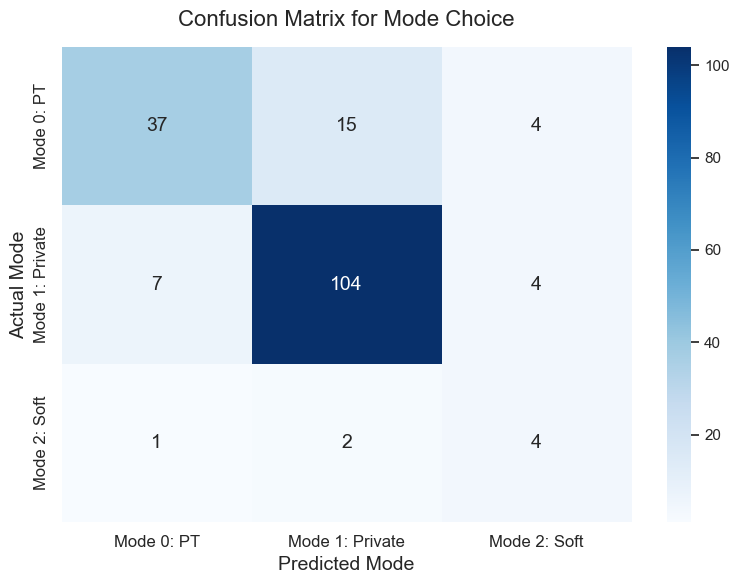

In [65]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                 xticklabels=['Mode 0: PT', 'Mode 1: Private', 'Mode 2: Soft'], 
                 yticklabels=['Mode 0: PT', 'Mode 1: Private', 'Mode 2: Soft'],
                 annot_kws={"size": 14}) 

plt.title('Confusion Matrix for Mode Choice', fontsize=16, pad=15)
plt.xlabel('Predicted Mode', fontsize=14)
plt.ylabel('Actual Mode', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [66]:
groups = {
    "Socio-demographic": ['age', 'Gender', 'Education', 'BirthYear', 'LangCode', 'FamilSitu', 'NbHousehold', 'NbChild'],
    "Vehicle": ['NbCar', 'NbMoto', 'CarAvail'],
    "Spatial": ['UrbRur', 'TypeCommune', 'ClassifCodeLine', 'Region', 'frequency'],
    "Trip": ['TimePT', 'TimeCar', 'InVehicleTime', 'WalkingTimePT', 'WaitingTimePT', 
                'distance_km', 'NbTransf', 'MarginalCostPT', 'CostCar'],
    "History": ['TripPurpose', 'DestAct', 'NbTrajects', 'FreqTripHouseh', 
                      'ModeToSchool', 'ResidChild', 'FreqTrainPar', 'FreqOtherPar'],
    "Attitudes": ['Envir01', 'Envir05', 'Mobil01', 'Mobil04', 'Mobil08', 'Mobil13', 
             'Mobil15', 'Mobil23', 'ResidCh05', 'ResidCh07', 'LifSty02', 
             'LifSty06', 'LifSty08', 'LifSty11']}

In [67]:
# Zorg dat feature names bestaan
feature_names = X.columns

# Coefficients ophalen
coef = model.coef_

# Create dataframe 
coef_df = pd.DataFrame(coef, columns=feature_names)

# Add mode labels
coef_df['Mode'] = model.classes_

# Set Mode as index
coef_df = coef_df.set_index('Mode')

# Transpose 
coef_df_T = coef_df.T

# choose one for normal, two for abs value
#coef_used = coef_df_T.copy()       
coef_used = coef_df_T.abs()       

# impact average 
coef_used['mean_effect'] = coef_used.mean(axis=1)

# Sort
coef_used = coef_used.sort_values(by='mean_effect', ascending=False)

print(coef_used)

Mode                   0.0       1.0       2.0  mean_effect
TimeCar           2.308972  0.565271  1.743700     1.539314
NbTrajects        0.621001  0.738785  1.359786     0.906524
InVehicleTime     0.519935  0.758598  1.278533     0.852355
WaitingTimePT     1.217683  0.280101  0.937582     0.811789
ReportedDuration  0.543828  1.037999  0.494171     0.692000
...                    ...       ...       ...          ...
frequency         0.019935  0.074123  0.054188     0.049415
DestAct           0.065985  0.050155  0.015830     0.043990
Mobil06           0.057137  0.003475  0.053663     0.038092
FreqCarPar        0.007902  0.031247  0.023345     0.020831
Mobil22           0.009379  0.020531  0.029910     0.019940

[115 rows x 4 columns]


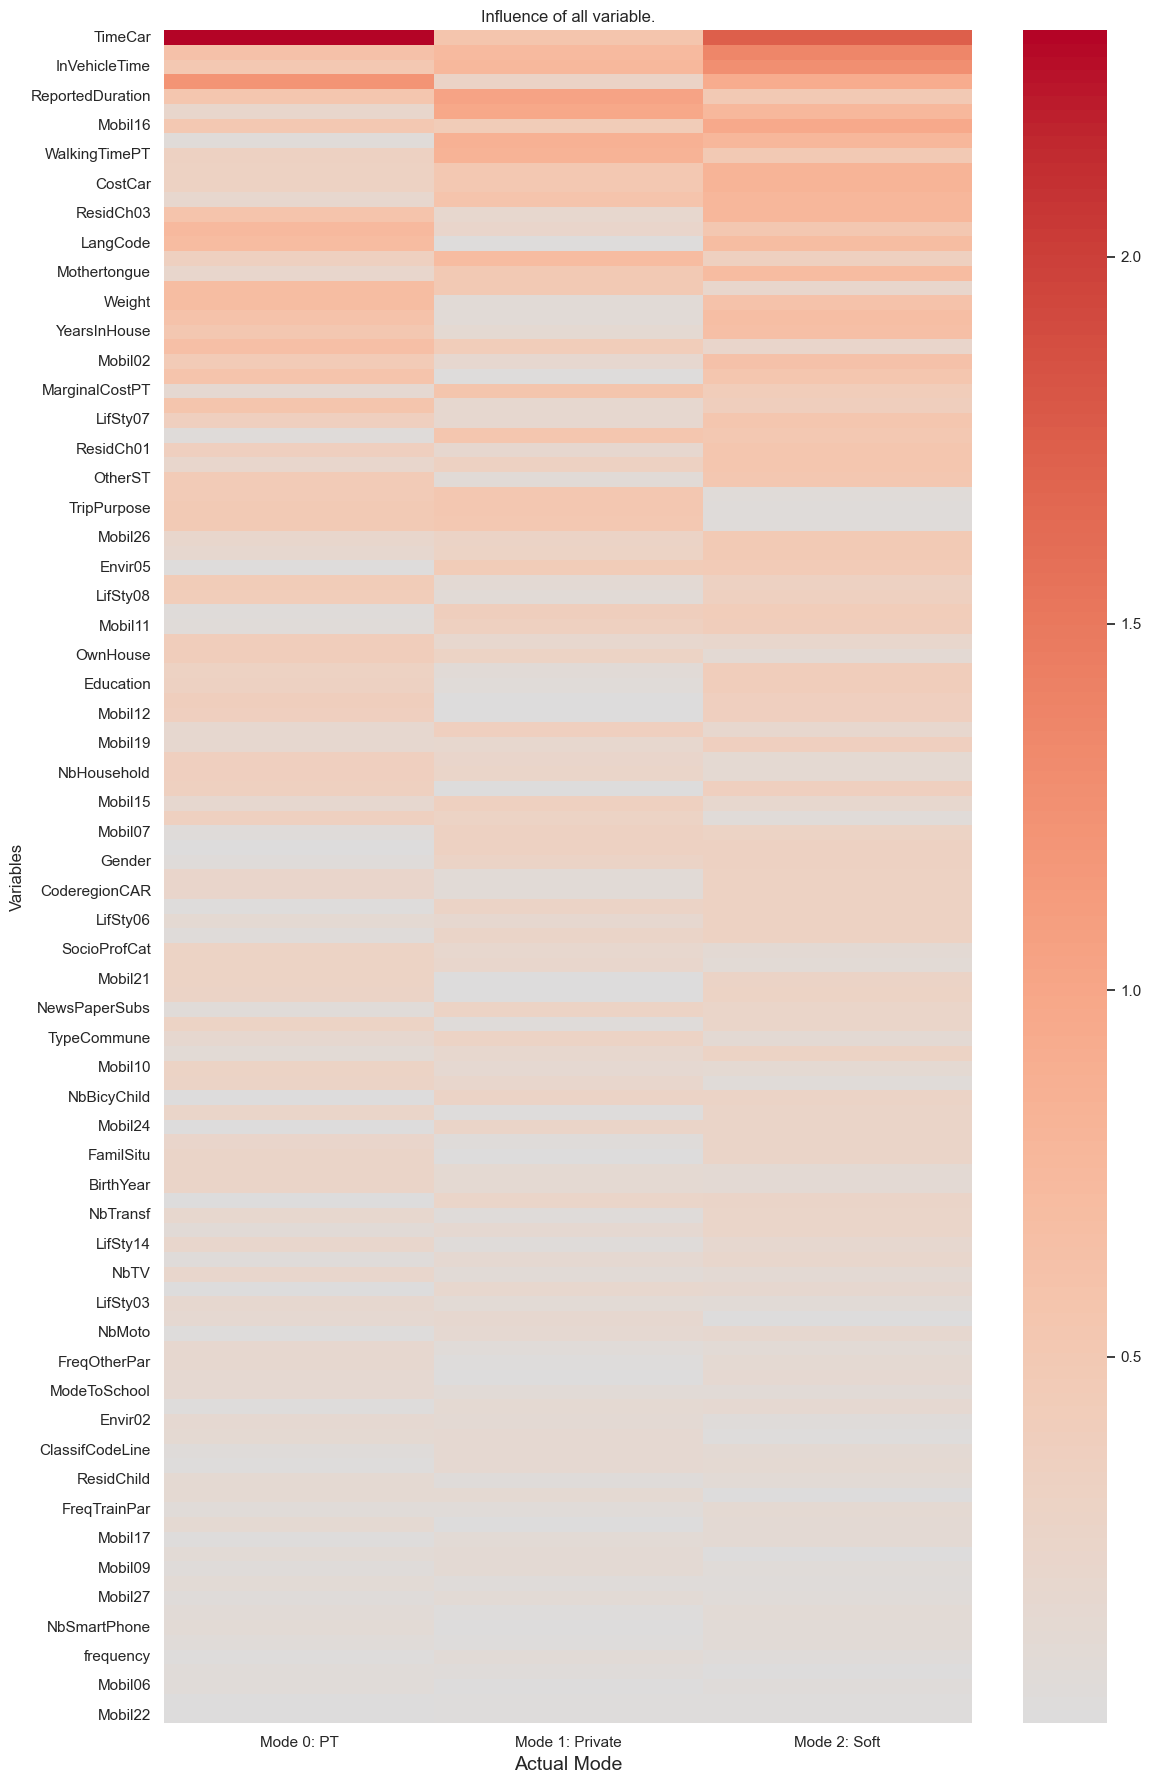

In [68]:
# Drop mean kolom
all_features = coef_used.drop(columns=['mean_effect'], errors='ignore')

plt.figure(figsize=(12, 18))

sns.heatmap(all_features, 
            cmap='coolwarm',
            center=0,
            xticklabels=['Mode 0: PT', 'Mode 1: Private', 'Mode 2: Soft'])

plt.title("Influence of all variable.")
plt.xlabel('Actual Mode', fontsize=14)
plt.ylabel("Variables")

plt.tight_layout()
plt.show()

In [69]:
group_mode_importance = {}

for group_name, cols in groups.items():
    existing_cols = [col for col in cols if col in coef_df_T.index]
    
    subset = coef_df_T.loc[existing_cols]

    # choose one
    #subset_used = subset.copy()        # real value
    subset_used = subset.abs()       # abs value

    group_mode_importance[group_name] = subset_used.mean(axis=0)

# Create dataframe 
group_mode_df = pd.DataFrame(group_mode_importance).T

# Sort
group_mode_df['mean_total'] = group_mode_df.mean(axis=1)
group_mode_df = group_mode_df.sort_values(by='mean_total', ascending=False)
group_mode_df = group_mode_df.drop(columns=['mean_total'])

print(group_mode_df)

Mode                    0.0       1.0       2.0
Trip               0.590979  0.601575  0.835485
Socio-demographic  0.310231  0.117028  0.290592
Attitudes          0.192848  0.219765  0.254832
History            0.225049  0.197111  0.240860
Vehicle            0.067783  0.260500  0.324650
Spatial            0.127305  0.135530  0.141354


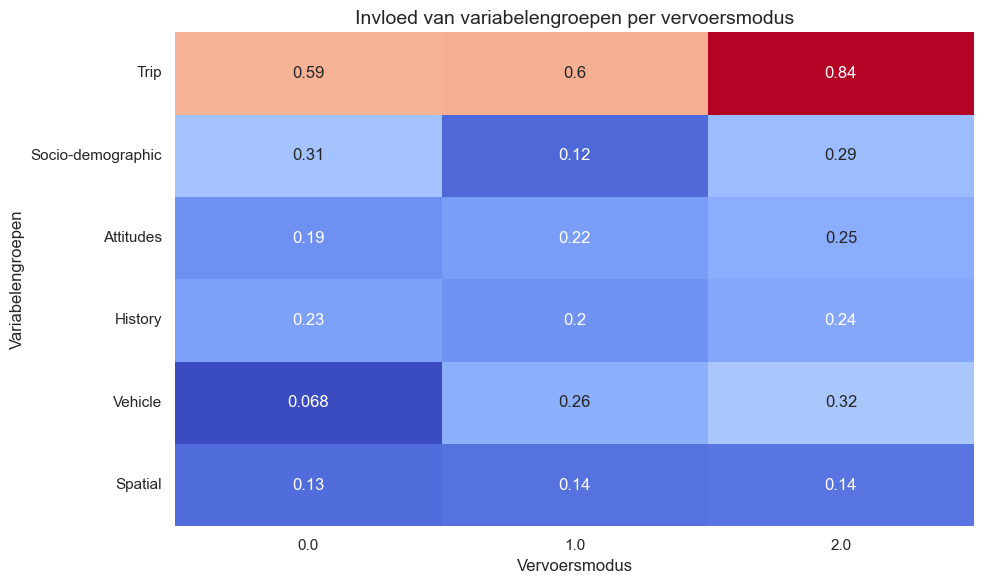

In [70]:
plt.figure(figsize=(10, 6))

sns.heatmap(group_mode_df, 
            annot=True, 
            cmap='coolwarm', 
            cbar=0)

plt.title("Invloed van variabelengroepen per vervoersmodus", fontsize=14)
plt.xlabel("Vervoersmodus")
plt.ylabel("Variabelengroepen")

plt.tight_layout()
plt.show()

In [71]:
# Bereken permutation importance op test set

result = permutation_importance(
    model, 
    X_test_scaled, 
    y_test, 
    n_repeats=10, 
    random_state=42,
    scoring='accuracy'
)

# Maak dataframe
perm_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
})

# Sorteer
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=False)

print(perm_importance_df)


              Feature  Importance
7             TimeCar    0.109551
111  ReportedDuration    0.065730
108       distance_km    0.036517
4       WaitingTimePT    0.035393
95        TripPurpose    0.033146
..                ...         ...
16           Internet   -0.001685
104      FreqTrainPar   -0.002247
110      ModeToSchool   -0.002247
15               NbTV   -0.002809
22       NbRoomsHouse   -0.003371

[115 rows x 2 columns]


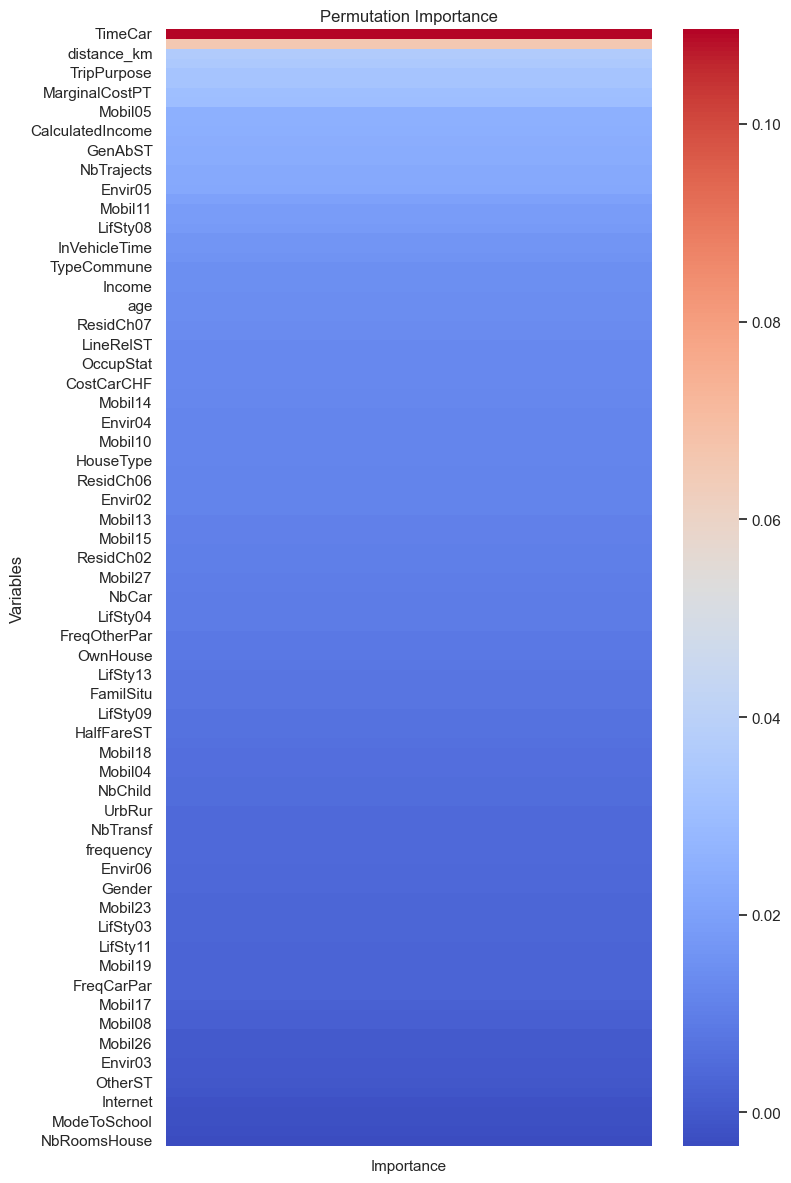

In [72]:
plt.figure(figsize=(8, 12))

sns.heatmap(
    perm_importance_df.set_index('Feature'),
    cmap='coolwarm',
    annot=False
)

plt.title("Permutation Importance")
plt.ylabel("Variables")

plt.tight_layout()
plt.show()

In [73]:
group_perm_importance = {}

for group_name, cols in groups.items():
    existing_cols = [col for col in cols if col in perm_importance_df['Feature'].values]
    
    subset = perm_importance_df[perm_importance_df['Feature'].isin(existing_cols)]
    
    group_perm_importance[group_name] = subset['Importance'].mean()

group_perm_df = pd.DataFrame.from_dict(
    group_perm_importance, 
    orient='index', 
    columns=['Importance']
)

# Sorteer
group_perm_df = group_perm_df.sort_values(by='Importance', ascending=False)

print(group_perm_df)

                   Importance
Trip                 0.034395
Socio-demographic    0.011096
Attitudes            0.009952
History              0.009691
Spatial              0.007640
Vehicle              0.003558


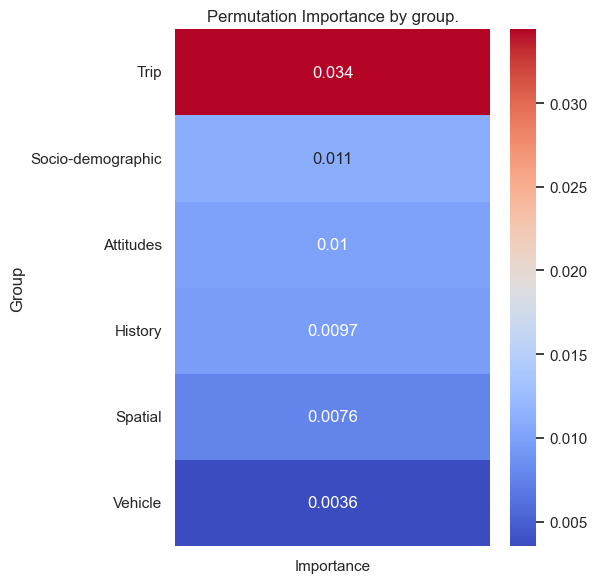

In [74]:
plt.figure(figsize=(6, 6))

sns.heatmap(
    group_perm_df,
    annot=True,
    cmap='coolwarm'
)

plt.title("Permutation Importance by group.")
plt.ylabel("Group")

plt.tight_layout()
plt.show()